<div align="center">

# <span style="color:#2E86C1;"> Tutorial 2: Newton's Method & Gradient Descent</span>

**Author:** [<span style="color:#8E44AD;">Dr. D Bhanu Prakash</span>](https://dbhanuprakash233.github.io)

<img src="https://github.com/dbhanuprakash233/SSSIHL_DBP/blob/main/assets/SssihlLogo.png?raw=true" alt="University Logo" width="80"/>

**<span style="color:#16A085;">Sri Sathya Sai Institute of Higher Learning</span>**  
<span style="color:#5D6D7E;">Prasanthi Nilayam - 515 134, Andhra Pradesh, India.</span>

**Course:** <span style="color:#D35400;">Optimization Techniques for Machine Learning</span>  
**Course Code:** <span style="color:#1ABC9C;">UMAM-502</span>

</div>

## Learning objectives

By the end of this notebook you should be able to:

1. Compute eigenvalues/eigenvectors both "by hand" (via an algorithm you code yourself) and using library routines, and explain *why* the algorithm works.
2. Compute derivatives, gradients, Jacobians, and Hessians numerically, symbolically, and (conceptually) via automatic differentiation.
3. Use eigen-structure of the Hessian to classify critical points (min / max / saddle) and to reason about convexity.
4. Implement Gradient Descent and Newton's Method from scratch and compare their convergence behaviour.
5. Understand *why* the condition number of the Hessian (ratio of largest to smallest eigenvalue) controls the speed of gradient descent.
6. Refactor procedural code into a clean, reusable **object-oriented** toolkit.

> **How to use this notebook:** Read the theory in each markdown cell, then run the code cell(s) that follow. Cells build on each other, so run them in order the first time through.



## 0. Setup

We will use:
- `numpy` for numerical linear algebra
- `scipy.optimize` as a "ground truth" to check our from-scratch implementations against
- `sympy` for symbolic differentiation
- `matplotlib` for visualizing convergence and geometry


In [1]:

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from scipy import optimize as scipy_optimize

np.set_printoptions(precision=4, suppress=True)
plt.rcParams['figure.figsize'] = (6, 4)
plt.rcParams['axes.grid'] = True



## 1. Eigenvalues and Eigenvectors

### 1.1 Why optimization courses care about eigenvalues

For a twice-differentiable function $f:\mathbb{R}^n \to \mathbb{R}$, the local behaviour near a critical point $\mathbf{x}^*$ (where $\nabla f(\mathbf{x}^*) = \mathbf{0}$) is governed by the **Hessian** $H = \nabla^2 f(\mathbf{x}^*)$:

- If all eigenvalues of $H$ are **positive**, $\mathbf{x}^*$ is a local **minimum**.
- If all eigenvalues are **negative**, $\mathbf{x}^*$ is a local **maximum**.
- If eigenvalues have **mixed signs**, $\mathbf{x}^*$ is a **saddle point**.
- The **ratio** of the largest to smallest eigenvalue (the *condition number*) tells us how "stretched" the bowl around the minimum is — and directly controls how fast gradient descent converges.

So before we optimize anything, we need solid tools for eigenvalues/eigenvectors.

### 1.2 Definition

For a square matrix $A \in \mathbb{R}^{n\times n}$, a nonzero vector $\mathbf{v}$ and scalar $\lambda$ satisfying

$$A\mathbf{v} = \lambda \mathbf{v}$$

are called an **eigenvector** and its corresponding **eigenvalue**. Geometrically: $A$ only *stretches/shrinks* $\mathbf{v}$ (by factor $\lambda$) without rotating it off its own line.


In [2]:

# A small symmetric matrix (Hessians in optimization are always symmetric)
A = np.array([[4.0, 1.0],
              [1.0, 3.0]])

eigvals, eigvecs = np.linalg.eig(A)
print("Eigenvalues:", eigvals)
print("Eigenvectors (columns):\n", eigvecs)

# Sanity check: A v = lambda v  for each eigenpair
for i in range(len(eigvals)):
    lhs = A @ eigvecs[:, i]
    rhs = eigvals[i] * eigvecs[:, i]
    print(f"lambda_{i} = {eigvals[i]:.4f}  ->  ||Av - lambda v|| = {np.linalg.norm(lhs - rhs):.2e}")


Eigenvalues: [4.618 2.382]
Eigenvectors (columns):
 [[ 0.8507 -0.5257]
 [ 0.5257  0.8507]]
lambda_0 = 4.6180  ->  ||Av - lambda v|| = 0.00e+00
lambda_1 = 2.3820  ->  ||Av - lambda v|| = 2.22e-16



### 1.3 Implementing the Power Iteration method from scratch

`np.linalg.eig` is a black box (it uses the QR algorithm internally). To really understand eigenvectors, let's implement **power iteration**, the simplest algorithm that finds the eigenvector associated with the **largest-magnitude eigenvalue**.

**Idea:** Repeatedly apply $A$ to a random vector and renormalize. Any starting vector has *some* component along the dominant eigenvector; repeated multiplication by $A$ amplifies that component relative to the others because $\lambda_{\max}$ dominates geometrically.

$$\mathbf{v}_{k+1} = \frac{A\mathbf{v}_k}{\|A\mathbf{v}_k\|}, \qquad \lambda_{\max} \approx \mathbf{v}_k^\top A \mathbf{v}_k \text{ (Rayleigh quotient)}$$


Power iteration eigenvalue : 4.618033988749895
Power iteration eigenvector: [0.8507 0.5257]
numpy dominant eigenvalue  : 4.618033988749895


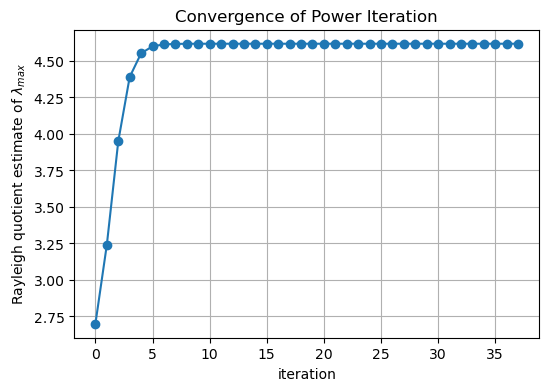

In [3]:

def power_iteration(A, num_iter=100, tol=1e-10, seed=0):
    '''Find the dominant eigenvalue/eigenvector of a square matrix A.

    Parameters
    ----------
    A : (n, n) ndarray
    num_iter : maximum number of iterations
    tol : stop early if the eigenvector estimate stops changing

    Returns
    -------
    eigenvalue : float
    eigenvector : (n,) ndarray, unit norm
    history : list of Rayleigh-quotient estimates (for convergence plotting)
    '''
    rng = np.random.default_rng(seed)
    n = A.shape[0]
    v = rng.standard_normal(n)
    v = v / np.linalg.norm(v)

    history = []
    for _ in range(num_iter):
        v_new = A @ v
        v_new = v_new / np.linalg.norm(v_new)
        lam = v_new @ A @ v_new          # Rayleigh quotient
        history.append(lam)
        if np.linalg.norm(v_new - v) < tol:
            v = v_new
            break
        v = v_new
    return lam, v, history


lam_pow, v_pow, hist = power_iteration(A)
print("Power iteration eigenvalue :", lam_pow)
print("Power iteration eigenvector:", v_pow)
print("numpy dominant eigenvalue  :", eigvals[np.argmax(np.abs(eigvals))])

plt.plot(hist, marker='o')
plt.xlabel("iteration")
plt.ylabel("Rayleigh quotient estimate of $\\lambda_{max}$")
plt.title("Convergence of Power Iteration")
plt.show()



**Note:** eigenvectors are only defined up to sign (and scale, before normalizing) — so `v_pow` may point in the opposite direction to numpy's eigenvector. That's still mathematically correct: if $A\mathbf v=\lambda \mathbf v$ then $A(-\mathbf v)=\lambda(-\mathbf v)$ too.

### 1.4 Symmetric matrices and quadratic forms

Because Hessians are symmetric, it's worth seeing directly how eigenvectors describe the *shape* of a quadratic bowl $f(\mathbf{x}) = \mathbf{x}^\top A \mathbf{x}$.


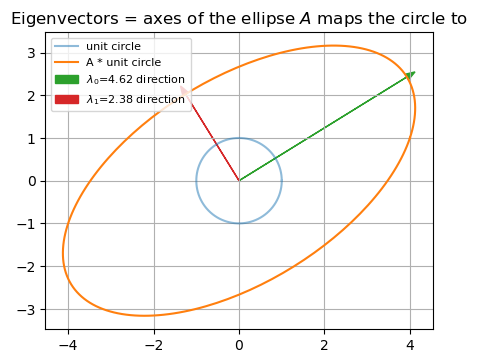

In [4]:

# Visualize how A stretches the unit circle along its eigenvector directions
theta = np.linspace(0, 2*np.pi, 200)
circle = np.vstack([np.cos(theta), np.sin(theta)])
transformed = A @ circle

fig, ax = plt.subplots(figsize=(5,5))
ax.plot(circle[0], circle[1], label="unit circle", alpha=0.5)
ax.plot(transformed[0], transformed[1], label="A * unit circle")

for i in range(2):
    vec = eigvecs[:, i] * eigvals[i]
    ax.arrow(0, 0, vec[0], vec[1], head_width=0.15, color=f"C{i+2}",
              label=f"$\\lambda_{i}$={eigvals[i]:.2f} direction")

ax.set_aspect('equal')
ax.legend(loc='upper left', fontsize=8)
ax.set_title("Eigenvectors = axes of the ellipse $A$ maps the circle to")
plt.show()



## 2. Derivatives: Numerical, Symbolic, and Automatic

Optimization algorithms need $\nabla f$ (gradient) and often $\nabla^2 f$ (Hessian). There are three ways to obtain them in practice:

| Method | How it works | Pros | Cons |
|---|---|---|---|
| **Numerical (finite differences)** | Approximate $f'(x) \approx \frac{f(x+h)-f(x-h)}{2h}$ | Works for any black-box $f$ | Approximate, sensitive to step size $h$, slow in high dimensions |
| **Symbolic** | Manipulate the algebraic expression (e.g. with `sympy`) | Exact | Can "explode" in size; needs closed-form $f$ |
| **Automatic differentiation (AD)** | Decompose $f$ into elementary ops and apply the chain rule mechanically at each step | Exact *and* efficient | Needs a supporting framework (PyTorch/JAX); here we build a toy version |

### 2.1 Numerical differentiation


In [5]:

def numerical_gradient(f, x, h=1e-5):
    '''Central-difference gradient of scalar function f: R^n -> R at point x.'''
    x = np.asarray(x, dtype=float)
    grad = np.zeros_like(x)
    for i in range(len(x)):
        e = np.zeros_like(x)
        e[i] = h
        grad[i] = (f(x + e) - f(x - e)) / (2 * h)
    return grad


def numerical_hessian(f, x, h=1e-4):
    '''Central-difference Hessian of scalar function f: R^n -> R at point x.'''
    x = np.asarray(x, dtype=float)
    n = len(x)
    H = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            ei, ej = np.zeros(n), np.zeros(n)
            ei[i], ej[j] = h, h
            H[i, j] = (f(x + ei + ej) - f(x + ei - ej) - f(x - ei + ej) + f(x - ei - ej)) / (4 * h**2)
    return H


# Test function: f(x, y) = x^2 + 3xy + 4y^2   (a simple convex quadratic bowl)
def f_quad(x):
    return x[0]**2 + 3*x[0]*x[1] + 4*x[1]**2

x0 = np.array([1.0, 2.0])
print("Numerical gradient at (1,2):", numerical_gradient(f_quad, x0))
print("Numerical Hessian at (1,2):\n", numerical_hessian(f_quad, x0))


Numerical gradient at (1,2): [ 8. 19.]
Numerical Hessian at (1,2):
 [[2. 3.]
 [3. 8.]]



### 2.2 Symbolic differentiation with `sympy`

Let's verify the numerical results exactly.


In [6]:

x, y = sp.symbols('x y')
f_sym = x**2 + 3*x*y + 4*y**2

grad_sym = [sp.diff(f_sym, var) for var in (x, y)]
hess_sym = sp.hessian(f_sym, (x, y))

print("Symbolic gradient:", grad_sym)
print("Symbolic Hessian:\n", hess_sym)

# Evaluate the symbolic expressions at (1, 2) to compare with the numerical result
grad_at_point = [g.subs({x: 1, y: 2}) for g in grad_sym]
print("Symbolic gradient at (1,2):", grad_at_point)


Symbolic gradient: [2*x + 3*y, 3*x + 8*y]
Symbolic Hessian:
 Matrix([[2, 3], [3, 8]])
Symbolic gradient at (1,2): [8, 19]



### 2.3 (Optional) -- A toy automatic differentiation (forward-mode) engine

Real frameworks like PyTorch/JAX use AD, not finite differences or symbolic algebra, because AD is both **exact** and **efficient**. The core idea of *forward-mode* AD: track a value **and** its derivative together (a "dual number") and propagate both through every operation via the chain rule.


In [7]:

class Dual:
    '''A minimal dual number x + eps*dx supporting forward-mode autodiff.
    eps^2 = 0, so operations propagate derivatives automatically via the chain rule.
    '''
    def __init__(self, val, deriv=0.0):
        self.val = val
        self.deriv = deriv

    def __add__(self, other):
        other = other if isinstance(other, Dual) else Dual(other, 0.0)
        return Dual(self.val + other.val, self.deriv + other.deriv)
    __radd__ = __add__

    def __mul__(self, other):
        other = other if isinstance(other, Dual) else Dual(other, 0.0)
        # product rule: d(uv) = u'v + uv'
        return Dual(self.val * other.val, self.deriv * other.val + self.val * other.deriv)
    __rmul__ = __mul__

    def __sub__(self, other):
        other = other if isinstance(other, Dual) else Dual(other, 0.0)
        return Dual(self.val - other.val, self.deriv - other.deriv)

    def __pow__(self, n):
        # power rule: d(x^n) = n x^(n-1) dx
        return Dual(self.val ** n, n * self.val ** (n - 1) * self.deriv)

    def __repr__(self):
        return f"Dual(val={self.val}, deriv={self.deriv})"


def autodiff_derivative(f, x0):
    '''Derivative of a single-variable function f at x0, via forward-mode AD.'''
    x = Dual(x0, 1.0)   # seed: dx/dx = 1
    return f(x).deriv


# Example: f(x) = x^3 - 2x^2 + 5   =>  f'(x) = 3x^2 - 4x
f_single = lambda x: x**3 - 2*x**2 + 5
print("AD derivative at x=3:", autodiff_derivative(f_single, 3.0))
print("Analytic derivative at x=3 (3x^2-4x):", 3*3**2 - 4*3)


AD derivative at x=3: 15.0
Analytic derivative at x=3 (3x^2-4x): 15



## 3. Using Eigenvalues to Classify Critical Points and Check Convexity

Now we connect Sections 1 and 2. At a critical point ($\nabla f = 0$), the eigenvalues of $H=\nabla^2f$ tell us the point's nature (the **second derivative test**, generalized to $n$ dimensions).


In [8]:

def classify_critical_point(f, x_star, h=1e-4):
    grad = numerical_gradient(f, x_star, h=1e-5)
    H = numerical_hessian(f, x_star, h=h)
    eigvals = np.linalg.eigvalsh(H)   # eigvalsh: faster + numerically stable for symmetric matrices

    print(f"Point: {x_star}")
    print(f"Gradient (should be ~0): {grad}")
    print(f"Hessian eigenvalues: {eigvals}")

    if not np.allclose(grad, 0, atol=1e-3):
        print("=> Not a critical point (gradient is not zero here).")
        return

    if np.all(eigvals > 1e-8):
        print("=> Local MINIMUM (Hessian positive definite).")
    elif np.all(eigvals < -1e-8):
        print("=> Local MAXIMUM (Hessian negative definite).")
    elif np.any(eigvals > 1e-8) and np.any(eigvals < -1e-8):
        print("=> SADDLE POINT (Hessian indefinite).")
    else:
        print("=> Inconclusive (Hessian is singular / semi-definite): need higher-order info.")


# f(x,y) = x^2 - y^2  has a saddle at the origin
def f_saddle(v):
    return v[0]**2 - v[1]**2

classify_critical_point(f_saddle, np.array([0.0, 0.0]))
print()
classify_critical_point(f_quad, np.array([0.0, 0.0]))


Point: [0. 0.]
Gradient (should be ~0): [0. 0.]
Hessian eigenvalues: [-2.  2.]
=> SADDLE POINT (Hessian indefinite).

Point: [0. 0.]
Gradient (should be ~0): [0. 0.]
Hessian eigenvalues: [0.7574 9.2426]
=> Local MINIMUM (Hessian positive definite).



## 4. Gradient Descent from Scratch

Gradient descent moves against the gradient direction:

$$\mathbf{x}_{k+1} = \mathbf{x}_k - \alpha \nabla f(\mathbf{x}_k)$$

where $\alpha$ is the **learning rate / step size**.


In [9]:

def gradient_descent(f, x0, lr=0.1, num_iter=100, tol=1e-8, grad_fn=None):
    '''Vanilla gradient descent. Returns the trajectory of iterates for analysis/plotting.'''
    x = np.asarray(x0, dtype=float)
    trajectory = [x.copy()]
    for _ in range(num_iter):
        grad = grad_fn(x) if grad_fn is not None else numerical_gradient(f, x)
        x = x - lr * grad
        trajectory.append(x.copy())
        if np.linalg.norm(grad) < tol:
            break
    return x, np.array(trajectory)


x_min, traj = gradient_descent(f_quad, x0=[5.0, 5.0], lr=0.1, num_iter=200)
print("Gradient descent minimum:", x_min, " f(x*) =", f_quad(x_min))
print("Iterations used:", len(traj) - 1)


Gradient descent minimum: [ 0. -0.]  f(x*) = 5.77230497264287e-14
Iterations used: 200


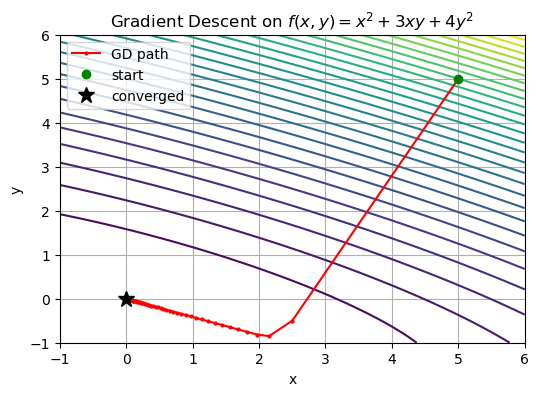

In [10]:

# Visualize the descent path on top of contours of f_quad
xs = np.linspace(-1, 6, 200)
ys = np.linspace(-1, 6, 200)
X, Y = np.meshgrid(xs, ys)
Z = X**2 + 3*X*Y + 4*Y**2

plt.contour(X, Y, Z, levels=30, cmap='viridis')
plt.plot(traj[:, 0], traj[:, 1], 'r.-', markersize=4, label='GD path')
plt.plot(*traj[0], 'go', label='start')
plt.plot(*traj[-1], 'k*', markersize=12, label='converged')
plt.legend()
plt.title("Gradient Descent on $f(x,y)=x^2+3xy+4y^2$")
plt.xlabel("x"); plt.ylabel("y")
plt.show()



### 4.1 Why the Hessian's condition number matters

The Hessian of `f_quad` is constant everywhere (it's a quadratic): $H = \begin{pmatrix}2 & 3\\ 3 & 8\end{pmatrix}$. Its eigenvalues set the *shape* of the bowl. Let's confirm gradient descent converges more slowly as the **condition number** $\kappa = \lambda_{max}/\lambda_{min}$ grows.


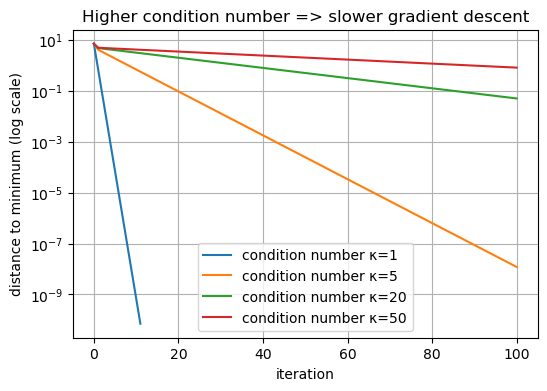

In [11]:

def make_quadratic(a, b):
    '''f(x,y) = a*x^2 + b*y^2 — eigenvalues of the Hessian are exactly 2a, 2b.'''
    def f(v):
        return a * v[0]**2 + b * v[1]**2
    def grad(v):
        return np.array([2*a*v[0], 2*b*v[1]])
    return f, grad

fig, ax = plt.subplots()
for b in [1, 5, 20, 50]:
    f_test, grad_test = make_quadratic(1, b)
    _, traj_test = gradient_descent(f_test, x0=[5.0, 5.0], lr=1.0/(2*b+1e-9)*0.9,
                                     num_iter=100, grad_fn=grad_test)
    residual = np.linalg.norm(traj_test, axis=1)
    ax.plot(residual, label=f"condition number κ={b}")

ax.set_yscale('log')
ax.set_xlabel("iteration")
ax.set_ylabel("distance to minimum (log scale)")
ax.set_title("Higher condition number => slower gradient descent")
ax.legend()
plt.show()



Notice how a larger condition number $\kappa$ produces a much slower (more "zig-zaggy") convergence, even with a well-tuned step size. This is one of the most important practical facts in optimization: **badly-conditioned problems are hard for gradient descent**, no matter how you tune the learning rate. This motivates preconditioning, momentum, and second-order methods like the one below.

## 5. Newton's Method

Newton's method uses **curvature** (the Hessian) to take smarter steps:

$$\mathbf{x}_{k+1} = \mathbf{x}_k - H^{-1}(\mathbf{x}_k)\, \nabla f(\mathbf{x}_k)$$

For a quadratic function, this converges in a **single step** — because it directly solves the local quadratic model exactly, rather than crawling down the gradient.


In [12]:

def newtons_method(f, x0, num_iter=20, tol=1e-10):
    x = np.asarray(x0, dtype=float)
    trajectory = [x.copy()]
    for _ in range(num_iter):
        grad = numerical_gradient(f, x)
        H = numerical_hessian(f, x)
        step = np.linalg.solve(H, grad)   # H^{-1} grad, without explicitly inverting H
        x = x - step
        trajectory.append(x.copy())
        if np.linalg.norm(grad) < tol:
            break
    return x, np.array(trajectory)


x_min_newton, traj_newton = newtons_method(f_quad, x0=[5.0, 5.0])
print("Newton's method minimum:", x_min_newton, " in", len(traj_newton)-1, "iterations")
print("(compare: gradient descent needed", len(traj)-1, "iterations for a similar tolerance)")


Newton's method minimum: [-0.  0.]  in 3 iterations
(compare: gradient descent needed 200 iterations for a similar tolerance)



### 5.1 Cross-check against `scipy.optimize`

Always validate from-scratch implementations against a trusted library.


In [13]:

result = scipy_optimize.minimize(f_quad, x0=[5.0, 5.0], method='BFGS')
print("scipy BFGS result:", result.x, " f(x*) =", result.fun)
print("our gradient descent :", x_min)
print("our Newton's method   :", x_min_newton)


scipy BFGS result: [-0. -0.]  f(x*) = 4.530241334967424e-13
our gradient descent : [ 0. -0.]
our Newton's method   : [-0.  0.]



## 6. A Preview of Where This Is Going: PCA as an Eigenvalue Problem

One reason ML courses front-load eigenvalues: **Principal Component Analysis (PCA)** is literally "find the eigenvectors of the covariance matrix," and it's derived by *solving an optimization problem* (maximize variance of a projection, subject to a unit-norm constraint) using Lagrange multipliers — which leads directly to an eigenvalue equation. You'll see this formally in a later lecture; for now, just notice that our power-iteration code from Section 1 is already 90% of a PCA implementation.


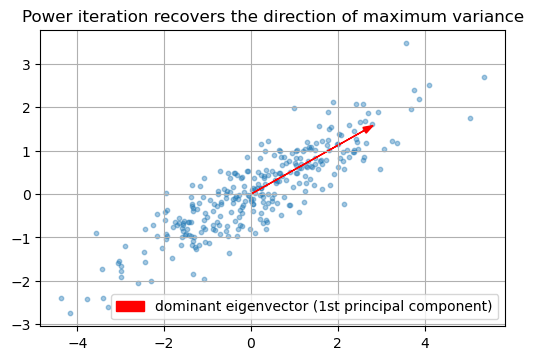

In [14]:

rng = np.random.default_rng(1)
# Correlated 2D data
mean = [0, 0]
cov = [[3, 1.5], [1.5, 1]]
data = rng.multivariate_normal(mean, cov, size=300)

cov_est = np.cov(data.T)
lam_dom, v_dom, _ = power_iteration(cov_est)

plt.scatter(data[:, 0], data[:, 1], s=10, alpha=0.4)
plt.arrow(0, 0, v_dom[0]*3, v_dom[1]*3, color='red', head_width=0.15,
          label='dominant eigenvector (1st principal component)')
plt.gca().set_aspect('equal')
plt.legend()
plt.title("Power iteration recovers the direction of maximum variance")
plt.show()



## 7. Exercises

Work through these in order. Exercises 7.1-7.3 are warm-ups. **Exercise 7.4 asks you to refactor everything above into an object-oriented toolkit** -- this is standard practice: procedural "notebook code" should eventually become a reusable library. **Exercise 7.5 is intentionally hard** -- it is designed to expose the gap between *pattern-matching* a solution and *actually reasoning* about one, so take your time with it.

---

### Exercise 7.1 -- Eigenvalues by hand vs. code (Warm-up)

For $A = \begin{pmatrix} 5 & 2 \\ 2 & 2 \end{pmatrix}$:

(a) By hand, solve $\det(A - \lambda I) = 0$ to find the eigenvalues symbolically.

(b) Find the corresponding (unit-norm) eigenvectors by hand.

(c) Verify your answers to (a) and (b) using `np.linalg.eig` **and** your `power_iteration` function from Section 1. Explain in a markdown cell why `power_iteration` only ever recovers *one* of the two eigenpairs, and describe (in words, no need to implement) how you would modify the algorithm to recover the second one. (Hint: think about *deflation* -- removing the found eigen-direction from $A$ before repeating power iteration.)

### Exercise 7.2 -- Finite-difference step size

Using `f_quad` from Section 2, compute the numerical gradient at $x=(1,2)$ for `h` in `[1e-1, 1e-3, 1e-5, 1e-7, 1e-10, 1e-14]` and compare each to the exact symbolic gradient. Plot the absolute error vs. `h` on a log-log scale. You should see the error *decrease* and then *increase again* for very small `h`. Explain why in a markdown cell (this is about floating point precision, not the calculus).

### Exercise 7.3 -- Newton's method can fail

Construct a **non-convex** 1-D function (e.g. $f(x) = x^4 - 3x^2$) and run your `newtons_method` starting from a few different `x0` values, including $x0=0$. Some starting points will cause Newton's method to diverge or behave erratically. Explain, using what you know about the Hessian at those points, *why* this happens. (Hint: what does Newton's method do when the Hessian is zero, or negative?)

---

### Exercise 7.4 -- Build an Object-Oriented Optimization Toolkit

Refactor the procedural functions from Sections 1-5 into a small, well-designed set of classes. Your design should include (at minimum):

1. **`DifferentiableFunction`** -- wraps a scalar function `f(x)` and exposes:
   - `.gradient(x)` (numerical, by default; central differences)
   - `.hessian(x)` (numerical, by default)
   - Optionally: accept user-supplied analytic `grad_fn`/`hess_fn` for speed/accuracy, falling back to numerical differentiation if not given.

2. **`EigenSolver`** -- given a symmetric matrix, exposes:
   - `.dominant_eigenpair()` implemented via power iteration
   - `.classify(H)` returning `"minimum" | "maximum" | "saddle" | "indefinite/inconclusive"` given a Hessian matrix

3. **An `Optimizer` abstract base class** with a common interface `.minimize(func: DifferentiableFunction, x0) -> OptimizationResult`, and at least two concrete subclasses:
   - `GradientDescentOptimizer(lr, num_iter, tol)`
   - `NewtonOptimizer(num_iter, tol)`

   Both should return a small `OptimizationResult` object/dataclass containing at least: `x_star`, `f_star`, `trajectory`, `n_iter`, `converged: bool`.

4. Demonstrate your toolkit by reproducing the Section 4/5 experiments (gradient descent vs. Newton on `f_quad`) using only your new classes, and by printing each optimizer's `classify()` verdict at the final point found.

**Design requirements:**
- Use `abc.ABC`/`@abstractmethod` for the `Optimizer` base class.
- Use Python's `dataclasses` for `OptimizationResult`.
- Your `Optimizer` subclasses should *not* duplicate the gradient/Hessian computation logic -- they should call methods on a `DifferentiableFunction` instance.
- Include docstrings and type hints.

A skeleton is provided below to get you started -- **do not just fill in the blanks mechanically; make design decisions of your own** (e.g., should `Optimizer.minimize` catch numerical errors? Should `DifferentiableFunction` cache repeated evaluations at the same point?).


In [15]:
"""
optimization_toolkit.py
========================

Object-Oriented implementation of the numerical tools built in the
"Optimization Techniques" course notebook:

    - Automatic differentiation via Dual numbers
    - Numerical / analytic gradients & Hessians  (DifferentiableFunction)
    - Eigen-analysis: power iteration + critical-point classification (EigenSolver)
    - Gradient Descent and Newton's Method        (Optimizer hierarchy)
    - A tiny PCA utility built by composing EigenSolver
    - A worked, intentionally hard example (Rosenbrock-type valley) that
      subclasses DifferentiableFunction with hand-derived analytic derivatives

Every class below is annotated with a comment naming the OOP concept(s)
it demonstrates, so this file doubles as reference material for
Exercise 7.4 (Build an Object-Oriented Optimization Toolkit).

------------------------------------------------------------------------
OOP CONCEPTS COVERED IN THIS FILE (quick index)
------------------------------------------------------------------------
1. Encapsulation        -> DifferentiableFunction (hides finite-diff details)
2. Operator overloading  -> Dual (dunder methods __add__, __mul__, __pow__, ...)
3. Abstraction/Interface -> Optimizer(ABC) with @abstractmethod
4. Inheritance           -> GradientDescentOptimizer, NewtonOptimizer,
                             QuadraticForm, RosenbrockLike
5. Polymorphism          -> run_all_optimizers() calls .minimize() on any
                             Optimizer subclass without an if/elif chain;
                             method overriding in QuadraticForm/RosenbrockLike
6. Composition ("has-a")  -> PCAAnalyzer (has a covariance matrix, uses
                             EigenSolver rather than inheriting from it)
7. Static / class methods -> EigenSolver's utility methods (no instance state)
8. Dataclasses            -> OptimizationResult (auto __init__/__repr__/__eq__)
9. Duck typing            -> any object with .gradient()/.hessian() works
                             with Optimizer subclasses, not just DifferentiableFunction
------------------------------------------------------------------------
"""

from __future__ import annotations

from abc import ABC, abstractmethod
from dataclasses import dataclass
from typing import Callable, Optional, List, Dict, Tuple

import numpy as np


# ============================================================================
# 1. DUAL NUMBERS  -- forward-mode Automatic Differentiation
# ============================================================================
class Dual:
    """
    A minimal dual number  x + eps*dx  (with eps**2 == 0 by definition),
    used to compute *exact* derivatives of single-variable functions by
    propagating (value, derivative) pairs through ordinary arithmetic.

    OOP CONCEPT -- Operator overloading (dunder methods):
        By implementing __add__, __sub__, __mul__, __pow__ etc., a Dual
        object can be dropped into any normal-looking arithmetic
        expression (e.g. `x**3 - 2*x**2 + 5`) and the chain rule is
        applied automatically underneath, without the caller ever
        writing calculus by hand. This is the same mechanism (operator
        overloading) that lets numpy arrays support `a + b`, `a * b`, etc.
    """

    def __init__(self, val: float, deriv: float = 0.0):
        self.val = val
        self.deriv = deriv

    def __add__(self, other: "Dual | float") -> "Dual":
        other = other if isinstance(other, Dual) else Dual(other, 0.0)
        return Dual(self.val + other.val, self.deriv + other.deriv)

    __radd__ = __add__  # OOP note: reuses __add__ since addition is commutative

    def __sub__(self, other: "Dual | float") -> "Dual":
        other = other if isinstance(other, Dual) else Dual(other, 0.0)
        return Dual(self.val - other.val, self.deriv - other.deriv)

    def __rsub__(self, other: float) -> "Dual":
        return Dual(other, 0.0) - self

    def __mul__(self, other: "Dual | float") -> "Dual":
        other = other if isinstance(other, Dual) else Dual(other, 0.0)
        # product rule: d(uv) = u'v + uv'
        return Dual(self.val * other.val, self.deriv * other.val + self.val * other.deriv)

    __rmul__ = __mul__

    def __pow__(self, n: float) -> "Dual":
        # power rule: d(x^n) = n * x^(n-1) * dx
        return Dual(self.val ** n, n * self.val ** (n - 1) * self.deriv)

    def __repr__(self) -> str:
        return f"Dual(val={self.val}, deriv={self.deriv})"

    @staticmethod
    def derivative(f: Callable[["Dual"], "Dual"], x0: float) -> float:
        """Exact derivative of a single-variable function f at x0 via forward-mode AD."""
        x = Dual(x0, 1.0)  # seed: dx/dx = 1
        return f(x).deriv


# ============================================================================
# 2. DIFFERENTIABLE FUNCTION -- encapsulates f(x), gradient(x), hessian(x)
# ============================================================================
class DifferentiableFunction:
    """
    Wraps a scalar-valued function f: R^n -> R and provides gradient /
    Hessian access, either via user-supplied analytic callables or via
    central-difference numerical approximation as a fallback.

    OOP CONCEPT -- Encapsulation:
        Callers only ever interact with .gradient(x) and .hessian(x).
        Whether those numbers come from an exact formula or from a
        finite-difference approximation is a private implementation
        detail hidden behind the public interface.

    OOP CONCEPT -- Composition:
        This class *holds* optional callables (grad_fn, hess_fn) rather
        than inheriting behaviour from them -- a "has-a" relationship.
    """

    def __init__(
        self,
        f: Callable[[np.ndarray], float],
        grad_fn: Optional[Callable[[np.ndarray], np.ndarray]] = None,
        hess_fn: Optional[Callable[[np.ndarray], np.ndarray]] = None,
        h: float = 1e-5,
    ):
        self.f = f
        self._grad_fn = grad_fn
        self._hess_fn = hess_fn
        self.h = h
        self._cache: Dict[Tuple[float, ...], float] = {}  # simple memoization

    def __call__(self, x: np.ndarray) -> float:
        """Evaluate f(x), memoizing repeated evaluations at the same point."""
        x = np.asarray(x, dtype=float)
        key = tuple(np.round(x, 12))
        if key not in self._cache:
            self._cache[key] = float(self.f(x))
        return self._cache[key]

    def gradient(self, x: np.ndarray) -> np.ndarray:
        """Gradient at x: analytic if grad_fn was supplied, else central differences."""
        x = np.asarray(x, dtype=float)
        if self._grad_fn is not None:
            return np.asarray(self._grad_fn(x), dtype=float)

        h = self.h
        grad = np.zeros_like(x)
        for i in range(len(x)):
            e = np.zeros_like(x)
            e[i] = h
            grad[i] = (self(x + e) - self(x - e)) / (2 * h)
        return grad

    def hessian(self, x: np.ndarray) -> np.ndarray:
        """Hessian at x: analytic if hess_fn was supplied, else central differences."""
        x = np.asarray(x, dtype=float)
        if self._hess_fn is not None:
            return np.asarray(self._hess_fn(x), dtype=float)

        h = max(self.h, 1e-4)  # Hessians need a larger step than gradients for stability
        n = len(x)
        H = np.zeros((n, n))
        for i in range(n):
            for j in range(n):
                ei, ej = np.zeros(n), np.zeros(n)
                ei[i], ej[j] = h, h
                H[i, j] = (
                    self(x + ei + ej) - self(x + ei - ej) - self(x - ei + ej) + self(x - ei - ej)
                ) / (4 * h * h)
        return H


class QuadraticForm(DifferentiableFunction):
    """
    f(x) = x^T A x for a symmetric matrix A.

    OOP CONCEPT -- Inheritance:
        QuadraticForm IS-A DifferentiableFunction. It reuses the parent's
        __call__/gradient/hessian machinery entirely, simply *supplying*
        exact analytic grad_fn/hess_fn to the parent constructor instead
        of overriding any methods directly.

    OOP CONCEPT -- Polymorphism:
        Any code written against DifferentiableFunction (e.g. the
        Optimizer classes below) works with a QuadraticForm instance
        without modification -- it doesn't need to know it's a subclass.
    """

    def __init__(self, A: np.ndarray):
        A = np.asarray(A, dtype=float)
        self.A = A
        super().__init__(
            f=lambda x: float(x @ A @ x),
            grad_fn=lambda x: (A + A.T) @ x,
            hess_fn=lambda x: (A + A.T),
        )


class RosenbrockLike(DifferentiableFunction):
    """
    f(x, y) = (x^2 - y)^2 + eps * (x - 1)^2   -- a "banana valley" function
    with a curved, ill-conditioned minimum, used as a stress test for
    optimizers (see Exercise 7.5 in the course notebook).

    Analytic derivatives (hand-derived, not from sympy):
        df/dx = 4x(x^2 - y) + 2*eps*(x - 1)
        df/dy = -2(x^2 - y)
        d2f/dx2  = 12x^2 - 4y + 2*eps
        d2f/dxdy = -4x
        d2f/dy2  = 2

    OOP CONCEPT -- Inheritance + Method reuse via composition:
        Like QuadraticForm, this subclass supplies exact analytic
        grad_fn/hess_fn closures to the DifferentiableFunction
        constructor rather than re-implementing __call__/gradient/hessian
        from scratch, demonstrating that "inheritance" here is really
        about reusing a well-designed *interface*, not just code.
    """

    def __init__(self, eps: float = 0.1):
        self.eps = eps

        def f(v):
            x, y = v
            return (x**2 - y) ** 2 + eps * (x - 1) ** 2

        def grad(v):
            x, y = v
            u = x**2 - y
            return np.array([4 * x * u + 2 * eps * (x - 1), -2 * u])

        def hess(v):
            x, y = v
            return np.array([[12 * x**2 - 4 * y + 2 * eps, -4 * x], [-4 * x, 2.0]])

        super().__init__(f=f, grad_fn=grad, hess_fn=hess)


# ============================================================================
# 3. EIGEN SOLVER -- power iteration + critical-point classification
# ============================================================================
class EigenSolver:
    """
    A namespace of eigen-analysis utilities: dominant eigenpair via power
    iteration, and Hessian-based classification of critical points.

    OOP CONCEPT -- Abstraction:
        Hides the iterative numerical procedure (repeated matrix-vector
        multiplication + renormalization) behind two simple, well-named
        entry points.

    OOP CONCEPT -- Static methods:
        Neither method needs per-instance state (no __init__ is even
        required), so they are declared `@staticmethod` and grouped
        under this class purely as a logical namespace -- you could call
        EigenSolver.classify(H) without ever creating an EigenSolver()
        instance.
    """

    @staticmethod
    def dominant_eigenpair(
        A: np.ndarray, num_iter: int = 200, tol: float = 1e-10, seed: int = 0
    ) -> Tuple[float, np.ndarray]:
        """Return (eigenvalue, eigenvector) for the largest-magnitude eigenvalue of A."""
        rng = np.random.default_rng(seed)
        n = A.shape[0]
        v = rng.standard_normal(n)
        v = v / np.linalg.norm(v)

        lam = 0.0
        for _ in range(num_iter):
            v_new = A @ v
            norm = np.linalg.norm(v_new)
            if norm < 1e-15:
                break
            v_new = v_new / norm
            lam = float(v_new @ A @ v_new)  # Rayleigh quotient
            if np.linalg.norm(v_new - v) < tol:
                v = v_new
                break
            v = v_new
        return lam, v

    @staticmethod
    def classify(H: np.ndarray, atol: float = 1e-8) -> str:
        """Classify a critical point from its Hessian's eigenvalue signs."""
        eigvals = np.linalg.eigvalsh(H)  # eigvalsh: stable + efficient for symmetric matrices
        if np.all(eigvals > atol):
            return "minimum"
        elif np.all(eigvals < -atol):
            return "maximum"
        elif np.any(eigvals > atol) and np.any(eigvals < -atol):
            return "saddle"
        return "indefinite/inconclusive"


def classify_critical_point(func: DifferentiableFunction, x_star: np.ndarray) -> str:
    """
    Convenience function combining DifferentiableFunction + EigenSolver:
    checks that x_star is (approximately) a critical point, then classifies it.
    """
    grad = func.gradient(x_star)
    if not np.allclose(grad, 0, atol=1e-3):
        return f"not a critical point (||grad|| = {np.linalg.norm(grad):.4g})"
    return EigenSolver.classify(func.hessian(x_star))


# ============================================================================
# 4. OPTIMIZATION RESULT -- a structured, immutable-by-convention record
# ============================================================================
@dataclass
class OptimizationResult:
    """
    OOP CONCEPT -- Dataclasses:
        @dataclass auto-generates __init__, __repr__, and __eq__ from the
        field declarations below, which is exactly what's needed for a
        class whose sole job is to *hold* structured data (a "value
        object" / DTO pattern) -- without hand-writing boilerplate.
    """

    x_star: np.ndarray
    f_star: float
    trajectory: np.ndarray
    n_iter: int
    converged: bool

    def __repr__(self) -> str:  # overriding the dataclass-generated __repr__ for readability
        return (
            f"OptimizationResult(x*={self.x_star}, f*={self.f_star:.6g}, "
            f"iters={self.n_iter}, converged={self.converged})"
        )


# ============================================================================
# 5. OPTIMIZER HIERARCHY -- abstract base class + two concrete strategies
# ============================================================================
class Optimizer(ABC):
    """
    OOP CONCEPT -- Abstraction / Interface definition:
        Declares the contract every concrete optimizer must satisfy
        (.minimize(func, x0) -> OptimizationResult) without saying *how*
        the minimization is actually performed. `@abstractmethod` means
        Optimizer itself can never be instantiated directly --
        `Optimizer()` would raise a TypeError.

    OOP CONCEPT -- Polymorphism:
        Any code that receives an `Optimizer` (see run_all_optimizers
        below) can call `.minimize(...)` on it without knowing or caring
        which concrete subclass it actually is. This is the "Strategy"
        design pattern: swap the optimizer object to swap the algorithm.
    """

    @abstractmethod
    def minimize(self, func: DifferentiableFunction, x0: np.ndarray) -> OptimizationResult:
        ...

    def __str__(self) -> str:
        return self.__class__.__name__


class GradientDescentOptimizer(Optimizer):
    """
    x_{k+1} = x_k - lr * grad f(x_k)

    OOP CONCEPT -- Inheritance:
        Reuses the Optimizer interface/contract; only the algorithm-
        specific update rule needs to be written here.
    """

    def __init__(self, lr: float = 0.1, num_iter: int = 500, tol: float = 1e-8):
        self.lr = lr
        self.num_iter = num_iter
        self.tol = tol

    def minimize(self, func: DifferentiableFunction, x0: np.ndarray) -> OptimizationResult:
        x = np.asarray(x0, dtype=float)
        trajectory = [x.copy()]
        converged = False

        for _ in range(self.num_iter):
            grad = func.gradient(x)
            x = x - self.lr * grad
            trajectory.append(x.copy())
            if np.linalg.norm(grad) < self.tol:
                converged = True
                break

        traj_arr = np.array(trajectory)
        return OptimizationResult(x, func(x), traj_arr, len(traj_arr) - 1, converged)

    def __str__(self) -> str:  # OOP: overriding Optimizer.__str__ (polymorphic dispatch)
        return f"GradientDescentOptimizer(lr={self.lr})"


class NewtonOptimizer(Optimizer):
    """
    x_{k+1} = x_k - H(x_k)^{-1} grad f(x_k)

    OOP CONCEPT -- Inheritance + Method overriding:
        Same base class and same public method name (.minimize) as
        GradientDescentOptimizer, but a completely different update rule
        -- classic example of two subclasses overriding one abstract
        method in different, interchangeable ways.
    """

    def __init__(self, num_iter: int = 50, tol: float = 1e-10):
        self.num_iter = num_iter
        self.tol = tol

    def minimize(self, func: DifferentiableFunction, x0: np.ndarray) -> OptimizationResult:
        x = np.asarray(x0, dtype=float)
        trajectory = [x.copy()]
        converged = False

        for _ in range(self.num_iter):
            grad = func.gradient(x)
            H = func.hessian(x)
            try:
                step = np.linalg.solve(H, grad)
            except np.linalg.LinAlgError:
                break  # singular Hessian: Newton's method cannot proceed from here
            x = x - step
            trajectory.append(x.copy())
            if np.linalg.norm(grad) < self.tol:
                converged = True
                break

        traj_arr = np.array(trajectory)
        return OptimizationResult(x, func(x), traj_arr, len(traj_arr) - 1, converged)

    def __str__(self) -> str:
        return "NewtonOptimizer()"


def run_all_optimizers(
    func: DifferentiableFunction, x0: np.ndarray, optimizers: List[Optimizer]
) -> Dict[str, OptimizationResult]:
    """
    OOP CONCEPT -- Polymorphism in action:
        This function loops over a *list of Optimizer objects* and calls
        `.minimize()` on each. There is no if/elif chain checking
        "is this a GradientDescentOptimizer or a NewtonOptimizer?" --
        each object simply responds to the same message in its own way.
    """
    return {str(opt): opt.minimize(func, x0) for opt in optimizers}


# ============================================================================
# 6. PCA ANALYZER -- composition over EigenSolver
# ============================================================================
class PCAAnalyzer:
    """
    Finds the dominant direction of variance in a dataset -- the first
    principal component -- by running power iteration on the covariance matrix.

    OOP CONCEPT -- Composition ("has-a", not "is-a"):
        PCAAnalyzer does NOT inherit from EigenSolver. It simply *uses*
        EigenSolver's static method internally. This is generally
        preferred over inheritance when there's no real "is-a"
        relationship -- a PCAAnalyzer is not a kind of EigenSolver, it
        just relies on one to do part of its job.
    """

    def __init__(self, data: np.ndarray):
        self.data = np.asarray(data, dtype=float)

    def covariance(self) -> np.ndarray:
        return np.cov(self.data.T)

    def dominant_direction(self) -> Tuple[float, np.ndarray]:
        """Returns (explained_variance, unit_vector) of the first principal component."""
        cov = self.covariance()
        return EigenSolver.dominant_eigenpair(cov)


# ============================================================================
# 7. DEMONSTRATION / SELF-TEST
# ============================================================================
def _demo() -> None:
    """
    Reproduces every experiment from the course notebook using only the
    OOP toolkit above -- this doubles as a smoke test.
    """
    print("=" * 70)
    print("1. EIGENVALUES / EIGENVECTORS")
    print("=" * 70)
    A = np.array([[4.0, 1.0], [1.0, 3.0]])
    lam_np, vec_np = np.linalg.eig(A)
    lam_pow, vec_pow = EigenSolver.dominant_eigenpair(A)
    print("numpy eigenvalues        :", lam_np)
    print("power-iteration eigenvalue:", lam_pow)
    print("power-iteration eigenvector:", vec_pow)

    print("\n" + "=" * 70)
    print("2. AUTOMATIC DIFFERENTIATION (Dual numbers)")
    print("=" * 70)
    f_single = lambda x: x**3 - 2 * x**2 + 5  # f'(x) = 3x^2 - 4x
    d = Dual.derivative(f_single, 3.0)
    print(f"AD derivative at x=3      : {d}")
    print(f"analytic derivative (3x^2-4x): {3*3**2 - 4*3}")

    print("\n" + "=" * 70)
    print("3. CRITICAL POINT CLASSIFICATION")
    print("=" * 70)
    quad = QuadraticForm(np.array([[2.0, 3.0], [3.0, 8.0]]))  # f = x^2+3xy+4y^2 (as x^T A x)
    saddle = DifferentiableFunction(lambda v: v[0] ** 2 - v[1] ** 2)
    print("quadratic bowl at origin  :", classify_critical_point(quad, np.array([0.0, 0.0])))
    print("x^2 - y^2 at origin       :", classify_critical_point(saddle, np.array([0.0, 0.0])))

    print("\n" + "=" * 70)
    print("4. GRADIENT DESCENT vs NEWTON'S METHOD  (polymorphism via run_all_optimizers)")
    print("=" * 70)
    optimizers: List[Optimizer] = [
        GradientDescentOptimizer(lr=0.1, num_iter=500),
        NewtonOptimizer(num_iter=50),
    ]
    results = run_all_optimizers(quad, x0=np.array([5.0, 5.0]), optimizers=optimizers)
    for name, res in results.items():
        print(f"{name:35s} -> {res}")

    print("\n" + "=" * 70)
    print("5. CONDITION NUMBER vs GRADIENT DESCENT ITERATIONS")
    print("=" * 70)
    for kappa in [1, 5, 20, 50]:
        A_test = np.array([[1.0, 0.0], [0.0, float(kappa)]])
        qf = QuadraticForm(A_test)
        gd = GradientDescentOptimizer(lr=0.9 / (2 * kappa + 1e-9), num_iter=2000, tol=1e-6)
        res = gd.minimize(qf, x0=np.array([5.0, 5.0]))
        print(f"condition number kappa={kappa:3d} -> converged in {res.n_iter} iterations")

    print("\n" + "=" * 70)
    print("6. ROSENBROCK-LIKE VALLEY (Exercise 7.5) -- GD vs Newton")
    print("=" * 70)
    rb = RosenbrockLike(eps=0.1)
    results_rb = run_all_optimizers(
        rb,
        x0=np.array([-1.5, 2.0]),
        optimizers=[
            GradientDescentOptimizer(lr=0.01, num_iter=20000, tol=1e-6),
            NewtonOptimizer(num_iter=100, tol=1e-6),
        ],
    )
    for name, res in results_rb.items():
        print(f"{name:35s} -> {res}")

    print("\n" + "=" * 70)
    print("7. PCA VIA COMPOSITION (PCAAnalyzer uses EigenSolver)")
    print("=" * 70)
    rng = np.random.default_rng(1)
    data = rng.multivariate_normal(mean=[0, 0], cov=[[3, 1.5], [1.5, 1]], size=300)
    pca = PCAAnalyzer(data)
    variance, direction = pca.dominant_direction()
    print(f"dominant variance direction: {direction}  (explained variance ~ {variance:.3f})")


if __name__ == "__main__":
    _demo()


1. EIGENVALUES / EIGENVECTORS
numpy eigenvalues        : [4.618 2.382]
power-iteration eigenvalue: 4.618033988749895
power-iteration eigenvector: [0.8507 0.5257]

2. AUTOMATIC DIFFERENTIATION (Dual numbers)
AD derivative at x=3      : 15.0
analytic derivative (3x^2-4x): 15

3. CRITICAL POINT CLASSIFICATION
quadratic bowl at origin  : minimum
x^2 - y^2 at origin       : saddle

4. GRADIENT DESCENT vs NEWTON'S METHOD  (polymorphism via run_all_optimizers)
GradientDescentOptimizer(lr=0.1)    -> OptimizationResult(x*=[-0. -0.], f*=1.58711e-18, iters=143, converged=True)
NewtonOptimizer()                   -> OptimizationResult(x*=[0. 0.], f*=0, iters=2, converged=True)

5. CONDITION NUMBER vs GRADIENT DESCENT ITERATIONS
condition number kappa=  1 -> converged in 9 iterations
condition number kappa=  5 -> converged in 83 iterations
condition number kappa= 20 -> converged in 352 iterations
condition number kappa= 50 -> converged in 889 iterations

6. ROSENBROCK-LIKE VALLEY (Exercise 7.5) -- 


---

### Exercise 7.5 -- A hard problem (designed to resist shortcut / pattern-matched answers)

Consider the function

$$f(x, y) = (x^2 - y)^2 + \epsilon\,(x - 1)^2, \qquad \epsilon > 0 \text{ a small constant.}$$

This is a variant of the classical **Rosenbrock-type "banana valley"** function, notorious as a stress test for optimizers because its Hessian is extremely ill-conditioned along a curved (not straight-line) valley -- unlike `f_quad` above, where the valley is a straight line and the condition number is *constant* everywhere.

**Part A (analysis -- do this by hand, then verify in code):**
Find *all* critical points of $f$ as a function of $\epsilon$, and classify each one (min/max/saddle) using the eigenvalues of the Hessian, **as a function of $\epsilon$** -- not just for one numeric value. You should discover that the number and type of critical points *changes* depending on the value of $\epsilon$ (this is called a **bifurcation**). Identify the critical value $\epsilon^*$ at which the qualitative picture changes, and explain what happens on either side of it.

**Part B (why this is hard for a black-box optimizer, and hard to answer generically):**
Explain, with reference to the eigenvalues of the Hessian along the curved valley floor $y = x^2$, why gradient descent with any *fixed* learning rate will be forced to either (i) diverge, or (ii) take an extremely large number of tiny steps, as it moves along the valley -- even though the valley floor itself has zero gradient in the "flat" direction. Relate this explicitly to the condition number analysis from Section 4.1, and explain precisely why that analysis (which assumed a constant Hessian) does *not* directly transfer to this problem.

**Part C (implementation):**
Implement `f`, its analytic gradient, and analytic Hessian (by hand-differentiating -- do not use `sympy` for this part, so you build the derivation skill). Run your `GradientDescentOptimizer` and `NewtonOptimizer` from Exercise 7.4 on `f` with $\epsilon = 0.1$ starting from $(x_0, y_0) = (-1.5, 2)$, and plot both trajectories on a contour plot of $f$. Report, quantitatively, how many iterations each required to reach $\|\nabla f\| < 10^{-6}$, and explain any qualitative differences you observe between the two trajectories' shapes (not just their iteration counts).

**Why this exercise is hard to shortcut:** a generic numeric answer for a *specific* $\epsilon$ is easy to produce; getting Part A right requires *symbolic* reasoning about how the critical-point structure changes as a parameter varies (a bifurcation analysis), which requires genuinely tracking cases rather than reporting a single evaluated example -- and Part B requires connecting a *local, pointwise* eigenvalue argument to *global, path-dependent* convergence behavior, which is easy to state informally but easy to get subtly wrong in the details (e.g., conflating the Hessian's condition number at a single point with the optimizer's actual convergence rate along a curved path).


In [16]:

# Space for Exercise 7.5 -- implement f, grad_f, hess_f here (by hand-derived formulas),
# then reuse your Exercise 7.4 classes to run both optimizers and produce the comparison plot.

def rosenbrock_like(v, eps=0.1):
    x, y = v
    return (x**2 - y)**2 + eps * (x - 1)**2

# TODO(student): grad_rosenbrock_like(v, eps), hess_rosenbrock_like(v, eps)
# TODO(student): bifurcation analysis for Part A (markdown cell + supporting symbolic/numeric check)
# TODO(student): trajectory comparison plot + iteration counts for Part C



---

## 8. Summary

| Concept | From-scratch tool built | Library equivalent |
|---|---|---|
| Eigenvalues/vectors | `power_iteration` | `np.linalg.eig`, `np.linalg.eigvalsh` |
| Numerical derivatives | `numerical_gradient`, `numerical_hessian` | `scipy.optimize.approx_fprime` |
| Symbolic derivatives | -- | `sympy.diff`, `sympy.hessian` |
| Automatic differentiation | `Dual` (toy forward-mode AD) | PyTorch `autograd`, JAX `grad` |
| Critical point classification | `classify_critical_point` | (no direct equivalent -- build it yourself!) |
| First-order optimization | `gradient_descent` | `scipy.optimize.minimize(method='CG'/'BFGS')` |
| Second-order optimization | `newtons_method` | `scipy.optimize.minimize(method='Newton-CG')` |

**Key takeaway:** every optimization algorithm you'll meet in this course (momentum, Adam, L-BFGS, trust-region methods, ...) is best understood as *a different strategy for using gradient and curvature information* to decide the next step. Section 4.1's condition-number experiment is the single most important intuition to carry forward: **the geometry of the loss landscape (captured by Hessian eigenvalues), not just the algorithm, determines how hard an optimization problem is.**
